# Brain age prediction on MS data (smoothed asymmetry, m12 scans)

## Imports and paths

In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pyreadstat

# fastMONAI / fastai / MONAI
from fastMONAI.vision_all import *
from fastai.learner import Learner
from fastai.losses import L1LossFlat
from fastai.metrics import mae
from monai.networks.nets import Regressor

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Root directory for thesis project
ms_root = Path("/hus/home/aaasen/Master_thesis")

image_dir = ms_root / "VBM_project_MS_m12" / "T1_scans"

# Metadata file (participants / clinical info)
ms_participants_path = ms_root / "Metadata_OFAMS" / "follow_up_info.csv"


# Path til edss.sav
edss_path = Path("/hus/home/aaasen/Master_thesis/Metadata_OFAMS/edss.sav")

## Load MS metadata

In [3]:
df_part = pd.read_csv(ms_participants_path)
df_part.head()

,Unnamed: 0,Patnr,Sex_OFAMS10,Age_BL_OFAMS,Age_OFAMS10,EDSS_score_10
0,1,101,1.0,35.0,47.0,2
1,2,103,0.0,24.0,36.0,1
2,3,104,1.0,48.0,59.0,"1,5"
3,4,201,0.0,50.0,62.0,2
4,5,202,1.0,31.0,43.0,0


In [4]:
df_part.dtypes

Unnamed: 0         int64
Patnr              int64
Sex_OFAMS10      float64
Age_BL_OFAMS     float64
Age_OFAMS10      float64
EDSS_score_10     object
dtype: object

In [5]:
df_part['Age_BL_OFAMS']= df_part['Age_BL_OFAMS'] + 1 # changes from the baseline age to the m12-age (1 years older)

df_part = df_part.rename(columns={
    'Patnr': 'participant_id',
    'Sex_OFAMS10': 'sex',
    'Age_BL_OFAMS': 'age_m12'})


df_part = df_part.drop(columns=["Unnamed: 0"])
df_part = df_part.drop(columns=["Age_OFAMS10"])
df_part = df_part.drop(columns=["EDSS_score_10"])
df_part["sex"] = df_part["sex"].map({0: "M", 1: "F"}) # 1=female, 0=male

In [6]:
df_part.head()

,participant_id,sex,age_m12
0,101,F,36.0
1,103,M,25.0
2,104,F,49.0
3,201,M,51.0
4,202,F,32.0


In [7]:
df_part.dtypes

participant_id      int64
sex                object
age_m12           float64
dtype: object

## Load EDSS data

In [8]:
edss_df, meta = pyreadstat.read_sav(edss_path)

edss_df.head()

,Patnr,BL_EDSSscore,M6_EDSSscore,M12_EDSSscore,M18_EDSSscore,M24_EDSSscore
0,101.0,1.5,2.0,2.0,2.0,2.0
1,103.0,2.5,1.0,1.0,1.0,0.0
2,104.0,1.5,1.5,2.0,1.5,1.5
3,201.0,1.5,2.5,2.5,2.5,2.5
4,202.0,1.0,1.0,1.0,0.0,0.0


In [9]:
edss_m12 = edss_df[["Patnr", "M12_EDSSscore"]].copy()

# Gi kolonnen samme navn som i df_part
edss_m12 = edss_m12.rename(columns={
    "Patnr": "participant_id",
    "M12_EDSSscore": "EDSS_m12"
})

edss_m12.head()

,participant_id,EDSS_m12
0,101.0,2.0
1,103.0,1.0
2,104.0,2.0
3,201.0,2.5
4,202.0,1.0


In [10]:
edss_m12["participant_id"] = edss_m12["participant_id"].astype(int)

In [11]:
edss_m12.dtypes

participant_id      int64
EDSS_m12          float64
dtype: object

In [12]:
df_part = df_part.merge(
    edss_m12,
    on="participant_id",
    how="left"
)

print("Number with m12-EDSS:", df_part["EDSS_m12"].notna().sum())
df_part.head()

Number with m12-EDSS: 88


,participant_id,sex,age_m12,EDSS_m12
0,101,F,36.0,2.0
1,103,M,25.0,1.0
2,104,F,49.0,2.0
3,201,M,51.0,2.5
4,202,F,32.0,1.0


## Remove subjects with missing age

In [13]:
# Removing rows with NaN values in age_m12 
df_part = df_part.dropna(subset=["age_m12"])
df_part.head()

,participant_id,sex,age_m12,EDSS_m12
0,101,F,36.0,2.0
1,103,M,25.0,1.0
2,104,F,49.0,2.0
3,201,M,51.0,2.5
4,202,F,32.0,1.0


In [14]:
min_age_new = df_part["age_m12"].min()
max_age_new = df_part["age_m12"].max()

print("Ages at month 24:")
print(f"Min age: {min_age_new}")
print(f"Max age: {max_age_new}")

Ages at month 24:
Min age: 20.0
Max age: 59.0


## Build dataframe linking images to subject metadata

In [15]:
from pathlib import Path
import pandas as pd

rows = []

# Finn alle m12 step4_warped-filer rekursivt
# Bytt pattern hvis asymmetrifilene dine har annet navn.
image_paths = sorted(image_dir.rglob("m12/mri/step4_warped/sAI_mwrp1sub-*_ses-m12_ce-GADOLINIUM_*_affine.nii*"))

print("Found image files:", len(image_paths))
if len(image_paths) > 0:
    print("Example:", image_paths[0])

for p in image_paths:
    fname = p.name

    # 1) Prøv å hente ID fra filnavn: "...sub-101..."
    participant_id = None
    if "sub-" in fname:
        try:
            participant_id = fname.split("sub-")[1].split("_")[0]
        except IndexError:
            participant_id = None

    # 2) Fallback: hent ID fra mappestruktur: .../T1_scans/101/m12/...
    if participant_id is None:
        # p.parts inneholder alle mappenavn i stien
        # Finn indeksen til "T1_scans" og ta neste element (= subject folder, f.eks. "101")
        parts = p.parts
        if "T1_scans" in parts:
            i = parts.index("T1_scans")
            if i + 1 < len(parts):
                participant_id = parts[i + 1]

    if participant_id is None:
        print("Could not parse subject ID from:", p)
        continue

    # Match metadata
    match = df_part[df_part["participant_id"].astype(str) == str(participant_id)]

    if len(match) == 1:
        rows.append({
            "image_path": str(p),
            "participant_id": str(participant_id),
            "sex": match["sex"].values[0],
            "age_m12": match["age_m12"].values[0],
            "EDSS_m12": match["EDSS_m12"].values[0],
        })
    else:
        print("Metadata not found (or not unique) for subject:", participant_id, "matches:", len(match))

df_ms = pd.DataFrame(rows)

print("Number of MS scans:", len(df_ms))
df_ms.head()

Found image files: 85
Example: /hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/101/m12/mri/step4_warped/sAI_mwrp1sub-101_ses-m12_ce-GADOLINIUM_T1w_affine.nii
Metadata not found (or not unique) for subject: 403 matches: 0
Number of MS scans: 84


,image_path,participant_id,sex,age_m12,EDSS_m12
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/101/m12/mri/step4_warped/sAI_mwrp1sub-101_ses-m12_ce-GADOLINIUM_T1w_affine.nii,101,F,36.0,2.0
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/103/m12/mri/step4_warped/sAI_mwrp1sub-103_ses-m12_ce-GADOLINIUM_T1w_affine.nii,103,M,25.0,1.0
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/104/m12/mri/step4_warped/sAI_mwrp1sub-104_ses-m12_ce-GADOLINIUM_T1w_affine.nii,104,F,49.0,2.0
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1101/m12/mri/step4_warped/sAI_mwrp1sub-1101_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1101,F,47.0,0.0
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1102/m12/mri/step4_warped/sAI_mwrp1sub-1102_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1102,F,40.0,2.0


## Build DataBlock

In [16]:
import pickle
from pathlib import Path

# Path til lagrede preprocessing-parametere
preproc_path = Path("/hus/home/aaasen/Master_thesis/smoothed_model/smoothed_preproc_params.pkl")

with open(preproc_path, "rb") as f:
    preproc = pickle.load(f)

resample = preproc["resample"]
reorder  = preproc["reorder"]

print("Preprocessing parameters loaded successfully.")
print("Resample:", resample)
print("Reorder:", reorder)

Preprocessing parameters loaded successfully.
Resample: [1.5, 1.5, 1.5]
Reorder: False


In [17]:
# Identical to baseline_train
in_shape = [1, 128, 160, 128]

item_tfms = [ZNormalization(), PadOrCrop(in_shape[1:])]

In [18]:
dblock = MedDataBlock(
    blocks=(ImageBlock(cls=MedImage), RegressionBlock),
    splitter=None,  # no splitting for inference
    get_x=ColReader("image_path"),
    get_y=ColReader("age_m12"),  # used only for analysis
    item_tfms=item_tfms,
    apply_reorder=reorder,
    target_spacing=resample
)

dls = dblock.dataloaders(df_ms, bs=4)

## Load model

In [19]:
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2
)

In [20]:
learn = Learner(
    dls,
    model,
    loss_func=L1LossFlat(), 
    metrics=[mae],
)

from pathlib import Path

learn.path = Path("/hus/home/aaasen/Master_thesis/smoothed_model")
learn.model_dir = ""   # siden filen ligger direkte i mappen

# Load trained weights
learn.load("smoothed_baseline_best")

Saved file doesn't contain an optimizer state.


In [21]:
learn.model.eval()

Regressor(
  (net): Sequential(
    (layer_0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (layer_1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
         

## Brain age predictions and brain age gap

In [22]:
test_dl = dls.test_dl(df_ms, with_labels=True)

In [23]:
preds, targs = learn.get_preds(dl=test_dl) # test = the whole dataset when splitter=None

y_pred = preds.squeeze().cpu().numpy()
y_true = targs.squeeze().cpu().numpy()

df_ms["predicted_age"] = y_pred
df_ms["brain_age_gap"] = y_pred - df_ms["age_m12"]

df_ms.head()

,image_path,participant_id,sex,age_m12,EDSS_m12,predicted_age,brain_age_gap
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/101/m12/mri/step4_warped/sAI_mwrp1sub-101_ses-m12_ce-GADOLINIUM_T1w_affine.nii,101,F,36.0,2.0,30.176420,-5.823580
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/103/m12/mri/step4_warped/sAI_mwrp1sub-103_ses-m12_ce-GADOLINIUM_T1w_affine.nii,103,M,25.0,1.0,27.650341,2.650341
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/104/m12/mri/step4_warped/sAI_mwrp1sub-104_ses-m12_ce-GADOLINIUM_T1w_affine.nii,104,F,49.0,2.0,32.442516,-16.557484
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1101/m12/mri/step4_warped/sAI_mwrp1sub-1101_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1101,F,47.0,0.0,44.397858,-2.602142
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1102/m12/mri/step4_warped/sAI_mwrp1sub-1102_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1102,F,40.0,2.0,49.260052,9.260052


## Bias correction

In [24]:
# Load bias correction parameters estimated on train set
a, b = np.load("smoothed_bias_correction_params.npy")
y_pred_bc = (y_pred - b) / a

df_ms["predicted_age_bc"] = (df_ms["predicted_age"] - b) 
df_ms["brain_age_gap_bc"] = df_ms["predicted_age_bc"] - df_ms["age_m12"]

In [25]:
df_ms.head()

,image_path,participant_id,sex,age_m12,EDSS_m12,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/101/m12/mri/step4_warped/sAI_mwrp1sub-101_ses-m12_ce-GADOLINIUM_T1w_affine.nii,101,F,36.0,2.0,30.176420,-5.823580,31.385036,-4.614964
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/103/m12/mri/step4_warped/sAI_mwrp1sub-103_ses-m12_ce-GADOLINIUM_T1w_affine.nii,103,M,25.0,1.0,27.650341,2.650341,28.858959,3.858959
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/104/m12/mri/step4_warped/sAI_mwrp1sub-104_ses-m12_ce-GADOLINIUM_T1w_affine.nii,104,F,49.0,2.0,32.442516,-16.557484,33.651134,-15.348866
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1101/m12/mri/step4_warped/sAI_mwrp1sub-1101_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1101,F,47.0,0.0,44.397858,-2.602142,45.606476,-1.393524
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1102/m12/mri/step4_warped/sAI_mwrp1sub-1102_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1102,F,40.0,2.0,49.260052,9.260052,50.468670,10.468670


## Prediction results

In [26]:
print(df_ms[["participant_id", "sex", "age_m12", "predicted_age", "brain_age_gap", "predicted_age_bc", "brain_age_gap_bc", "EDSS_m12"]].head())
print("N =", len(df_ms))
print("Mean BAG:", df_ms["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_ms["brain_age_gap_bc"].mean())
print("Std BAG:", df_ms["brain_age_gap"].std())
print("Std BAG (bias-corrected):", df_ms["brain_age_gap_bc"].std())

  participant_id sex  age_m12  predicted_age  brain_age_gap  predicted_age_bc  \
0            101   F     36.0      30.176420      -5.823580         31.385036   
1            103   M     25.0      27.650341       2.650341         28.858959   
2            104   F     49.0      32.442516     -16.557484         33.651134   
3           1101   F     47.0      44.397858      -2.602142         45.606476   
4           1102   F     40.0      49.260052       9.260052         50.468670   

   brain_age_gap_bc  EDSS_m12  
0         -4.614964       2.0  
1          3.858959       1.0  
2        -15.348866       2.0  
3         -1.393524       0.0  
4         10.468670       2.0  
N = 84
Mean BAG: -1.150983765011742
Mean BAG (bias-corrected): 0.05763426281156994
Std BAG: 9.319676204970033
Std BAG (bias-corrected): 9.319676336811307


## Quality Control (QC)

### Extreme outliers

Checking if the huge BAG is due to wrongfully done preprocessing, empty image etc. Manually checking these images.

In [27]:
df_ms.sort_values("brain_age_gap", key=lambda x: abs(x), ascending=False).head(5)

,image_path,participant_id,sex,age_m12,EDSS_m12,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
21,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1414/m12/mri/step4_warped/sAI_mwrp1sub-1414_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1414,F,28.0,1.0,55.855068,27.855068,57.063686,29.063686
61,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/705/m12/mri/step4_warped/sAI_mwrp1sub-705_ses-m12_ce-GADOLINIUM_T1w_affine.nii,705,F,20.0,1.0,47.308796,27.308796,48.517414,28.517414
16,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1406/m12/mri/step4_warped/sAI_mwrp1sub-1406_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1406,F,26.0,0.0,50.137032,24.137032,51.345650,25.345650
11,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/1401/m12/mri/step4_warped/sAI_mwrp1sub-1401_ses-m12_ce-GADOLINIUM_T1w_affine.nii,1401,F,23.0,3.5,43.284832,20.284832,44.493450,21.493450
80,/hus/home/aaasen/Master_thesis/VBM_project_MS_m12/T1_scans/901/m12/mri/step4_warped/sAI_mwrp1sub-901_ses-m12_ce-GADOLINIUM_T1w_affine.nii,901,NaN,53.0,3.5,35.101147,-17.898853,36.309765,-16.690235


Conclution: Nothing unusual with these smoothed asymmetry images.

In [28]:
# checking the input shape
xb, _ = dls.one_batch()
print(xb.shape)

torch.Size([4, 1, 128, 160, 128])


### Visualizing the 10 subjects with the largest and smallest BAG

Checking the visualizations if anything looks unusual.

In [29]:
# Top 10 best and worst predictions (abs bias-corrected error)
best_cases = df_ms.sort_values("brain_age_gap").head(10)
worst_cases = df_ms.sort_values("brain_age_gap", ascending=False).head(10)

In [30]:
best_cases[
    ["participant_id", "sex", "age_m12", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_m12"]
    ]

,participant_id,sex,age_m12,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_m12
80,901,NaN,53.0,35.101147,36.309765,-17.898853,-16.690235,3.5
60,704,F,45.0,27.282211,28.490829,-17.717789,-16.509171,2.5
2,104,F,49.0,32.442516,33.651134,-16.557484,-15.348866,2.0
79,815,M,46.0,30.205000,31.413616,-15.795000,-14.586384,1.0
25,1504,NaN,46.0,32.585518,33.794136,-13.414482,-12.205864,2.5
27,201,M,51.0,37.684544,38.893162,-13.315456,-12.106838,2.5
54,603,F,55.0,42.534447,43.743065,-12.465553,-11.256935,4.5
36,210,F,52.0,39.844608,41.053226,-12.155392,-10.946774,1.5
26,1505,M,39.0,27.036570,28.245186,-11.963430,-10.754814,0.0
72,808,M,51.0,39.332767,40.541386,-11.667233,-10.458614,1.5


In [31]:
worst_cases[
    ["participant_id", "sex", "age_m12", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_m12"]
    ]

,participant_id,sex,age_m12,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_m12
21,1414,F,28.0,55.855068,57.063686,27.855068,29.063686,1.0
61,705,F,20.0,47.308796,48.517414,27.308796,28.517414,1.0
16,1406,F,26.0,50.137032,51.345650,24.137032,25.345650,0.0
11,1401,F,23.0,43.284832,44.493450,20.284832,21.493450,3.5
65,709,F,35.0,46.986797,48.195415,11.986797,13.195415,2.0
15,1405,M,48.0,58.513718,59.722336,10.513718,11.722336,3.0
20,1412,M,34.0,44.009644,45.218262,10.009644,11.218262,2.0
8,1107,F,29.0,38.885361,40.093979,9.885361,11.093979,2.0
4,1102,F,40.0,49.260052,50.468670,9.260052,10.468670,2.0
68,803,F,31.0,39.701923,40.910542,8.701923,9.910542,0.0


In [32]:
def show_asymmetry_image(image_path, title=None, slice_idx=None):
    img = nib.load(image_path).get_fdata()

    # Default: mid axial slice
    if slice_idx is None:
        slice_idx = img.shape[2] // 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img[:, :, slice_idx].T, cmap="bwr", origin="lower")
    plt.colorbar(fraction=0.046)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

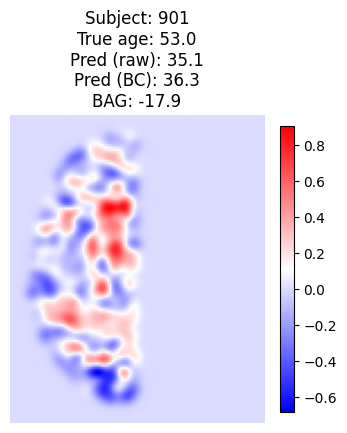

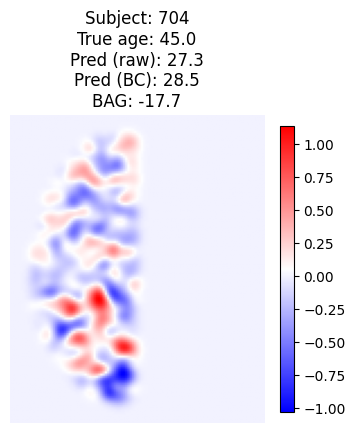

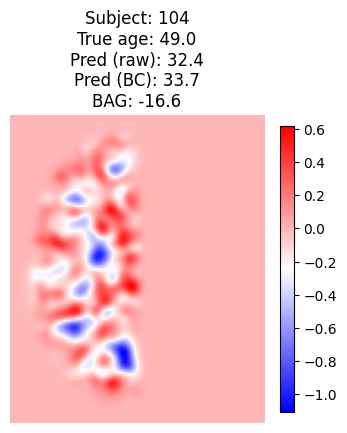

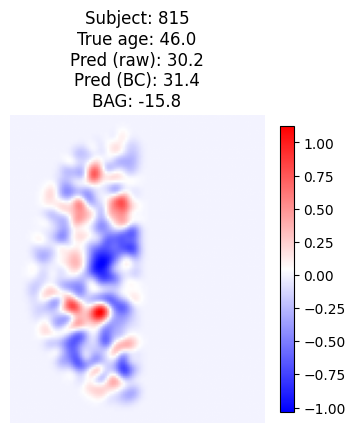

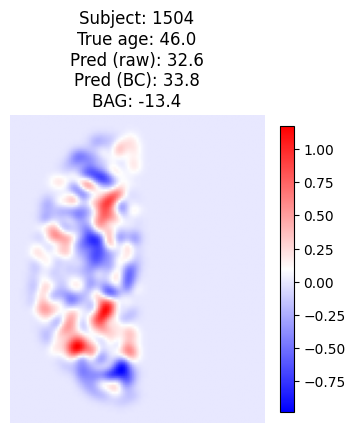

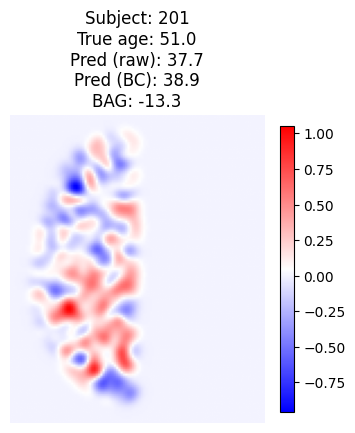

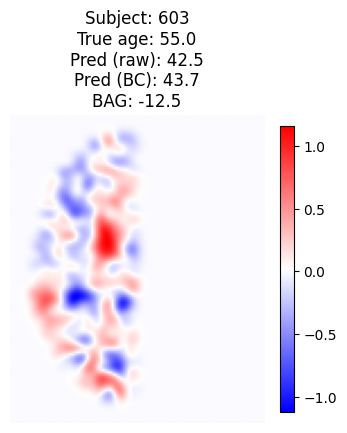

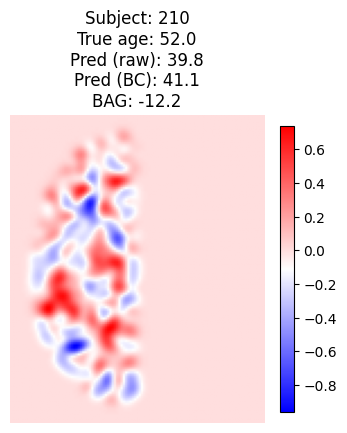

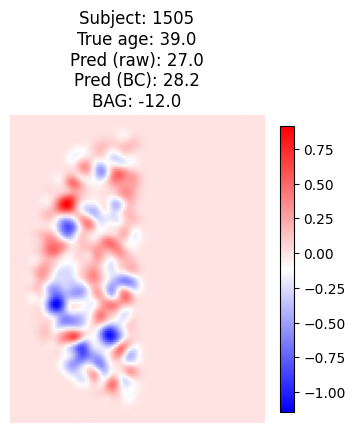

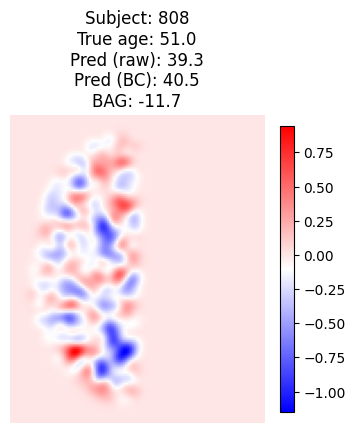

In [33]:
# Best cases sorted after bias-corrected predictions (smallest BAG)
for _, row in best_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_m12']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

# red/positive values: rightward asymmetry
# blue/negative values: leftward asymmetry

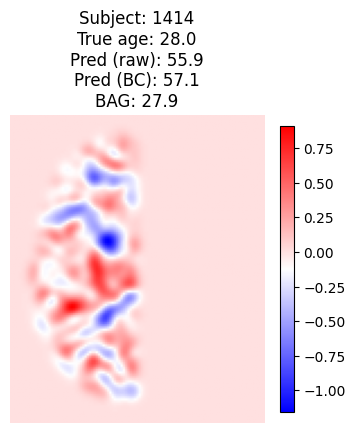

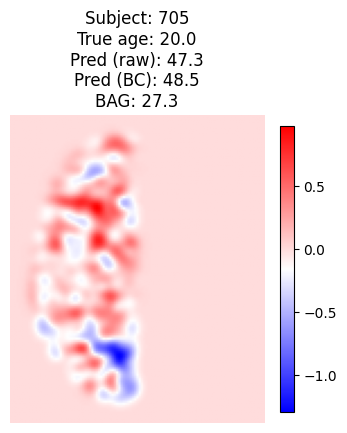

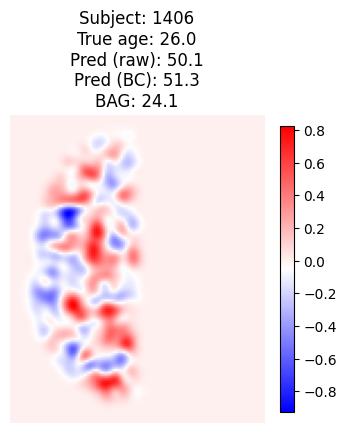

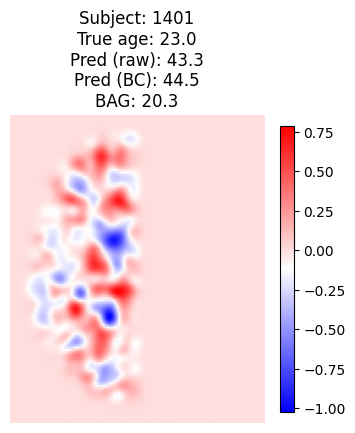

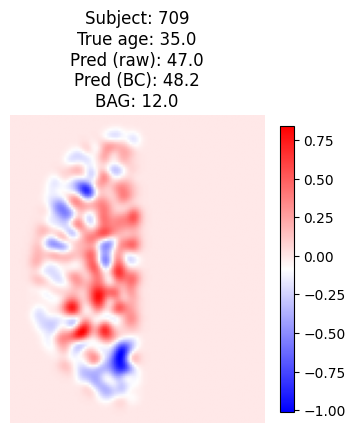

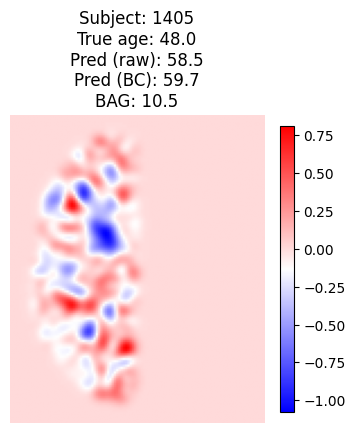

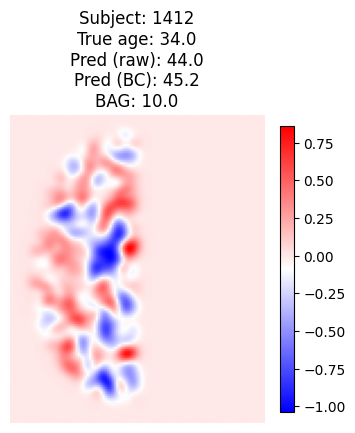

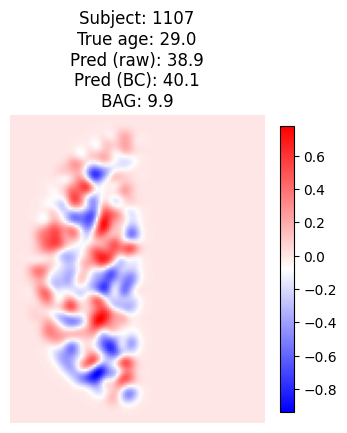

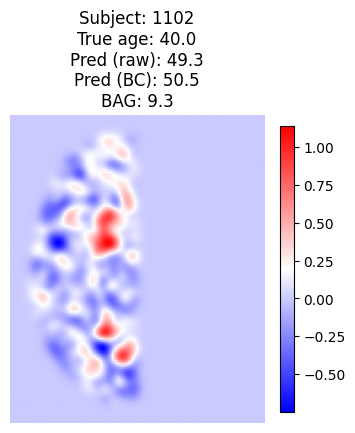

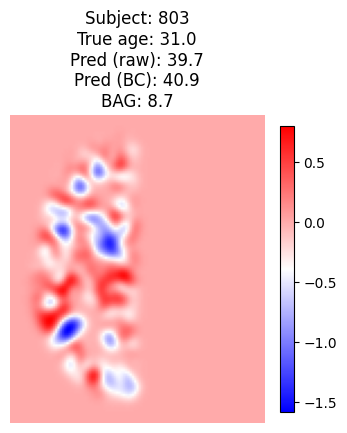

In [34]:
# Worst cases sorted after bias-corrected predictions (largest BAG)
for _, row in worst_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_m12']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

Conclusions: Nothing suspicious.

## Save results

In [64]:
#df_ms.to_csv("smoothed_MS_brain_age_predictions_m12.csv", index=False)